In [32]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path for custom modules
sys.path.append('../src')

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✅ Environment setup complete!")


✅ Environment setup complete!


In [33]:


# Load your house price dataset
data_path = Path('../data/raw/')
df = pd.read_csv(data_path / 'house_dataset.csv')

print(f"Dataset shape: {df.shape}")
df.head()




Dataset shape: (9200, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [37]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           9200 non-null   object 
 1   price          9200 non-null   float64
 2   bedrooms       9200 non-null   float64
 3   bathrooms      9200 non-null   float64
 4   sqft_living    9200 non-null   int64  
 5   sqft_lot       9200 non-null   int64  
 6   floors         9200 non-null   float64
 7   waterfront     9200 non-null   int64  
 8   view           9200 non-null   int64  
 9   condition      9200 non-null   int64  
 10  sqft_above     9200 non-null   int64  
 11  sqft_basement  9200 non-null   int64  
 12  yr_built       9200 non-null   int64  
 13  yr_renovated   9200 non-null   int64  
 14  street         9200 non-null   object 
 15  city           9200 non-null   object 
 16  statezip       9200 non-null   object 
 17  country        9200 non-null   object 
dtypes: float

In [10]:
# Data types and basic statistics
# print("\n=== DATA TYPES ===")
# print(df.dtypes)

print("\n=== STATISTICAL SUMMARY ===")
print(df["price"].describe())

# # Check for missing values
# print("\n=== MISSING VALUES ===")
# missing_values = df.isnull().sum()
# missing_percentage = (missing_values / len(df)) * 100
# missing_info = pd.DataFrame({
#     'Missing Count': missing_values,
#     'Missing Percentage': missing_percentage
# })
# print(missing_info[missing_info['Missing Count'] > 0])



=== STATISTICAL SUMMARY ===
count    9.200000e+03
mean     5.519630e+05
std      5.638041e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64


In [ ]:
# #filter price is 0

# # Set your threshold
# threshold = 1

# # Filter the dataframe
# low_price_df = df[df['price'] < threshold]

# # Get the count
# count = len(low_price_df)
# percentage = (count / len(df)) * 100

# print(f"Number of houses priced below {threshold}: {count}")
# print(f"Percentage of total data: {percentage:.2f}%")
# Number of houses priced below 1: 98
# Percentage of total data: 1.07%

# Set your threshold
# threshold = 5e6

# # Filter the dataframe
# high_price_df = df_clean[df_clean['price'] > threshold]

# # Get the count
# count = len(high_price_df)
# percentage = (count / len(df_clean)) * 100

# print(f"Number of houses priced below {threshold}: {count}")
# print(f"Percentage of total data: {percentage:.2f}%")
#  # shall we remove outliner (~1%) or we use clip data to handle outliner (~1%) ?

Number of houses priced below 1: 98
Percentage of total data: 1.07%


In [56]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and preprocess house price data.
    
    Args:
        df: Raw dataframe
        
    Returns:
        Cleaned dataframe
    """
    df_clean = df.copy()
    
    # cleaning functions

    # Remove rows where price is 0 or negative or more than 5 million (outliers)
    df_clean = df_clean[(df_clean['price'] > 1) & (df_clean['price'] < 5e6)]
    print(f"Removed {len(df) - len(df_clean)} rows with non-positive or outlier prices.")
    
    # (Use the code from previous analysis)
    
    return df_clean

def handle_outliers(series: pd.Series, method: str = 'iqr') -> pd.Series:
    """Handle outliers in a series."""
    if method == 'iqr':
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        return series.clip(lower, upper)
    
    return series

df_clean = clean_data(df)
print("✅ Data cleaning completed!")
print(len(df_clean))
# Save cleaned data
df_clean.to_csv('../data/processed/cleaned_house_data.csv', index=False)

Removed 104 rows with non-positive or outlier prices.
✅ Data cleaning completed!
9096


In [57]:

print("\n=== STATISTICAL SUMMARY ===")
print(df_clean["price"].describe())

df_clean.shape


=== STATISTICAL SUMMARY ===
count    9.096000e+03
mean     5.480383e+05
std      3.553570e+05
min      7.800000e+03
25%      3.260750e+05
50%      4.650000e+05
75%      6.572000e+05
max      4.668000e+06
Name: price, dtype: float64


(9096, 18)

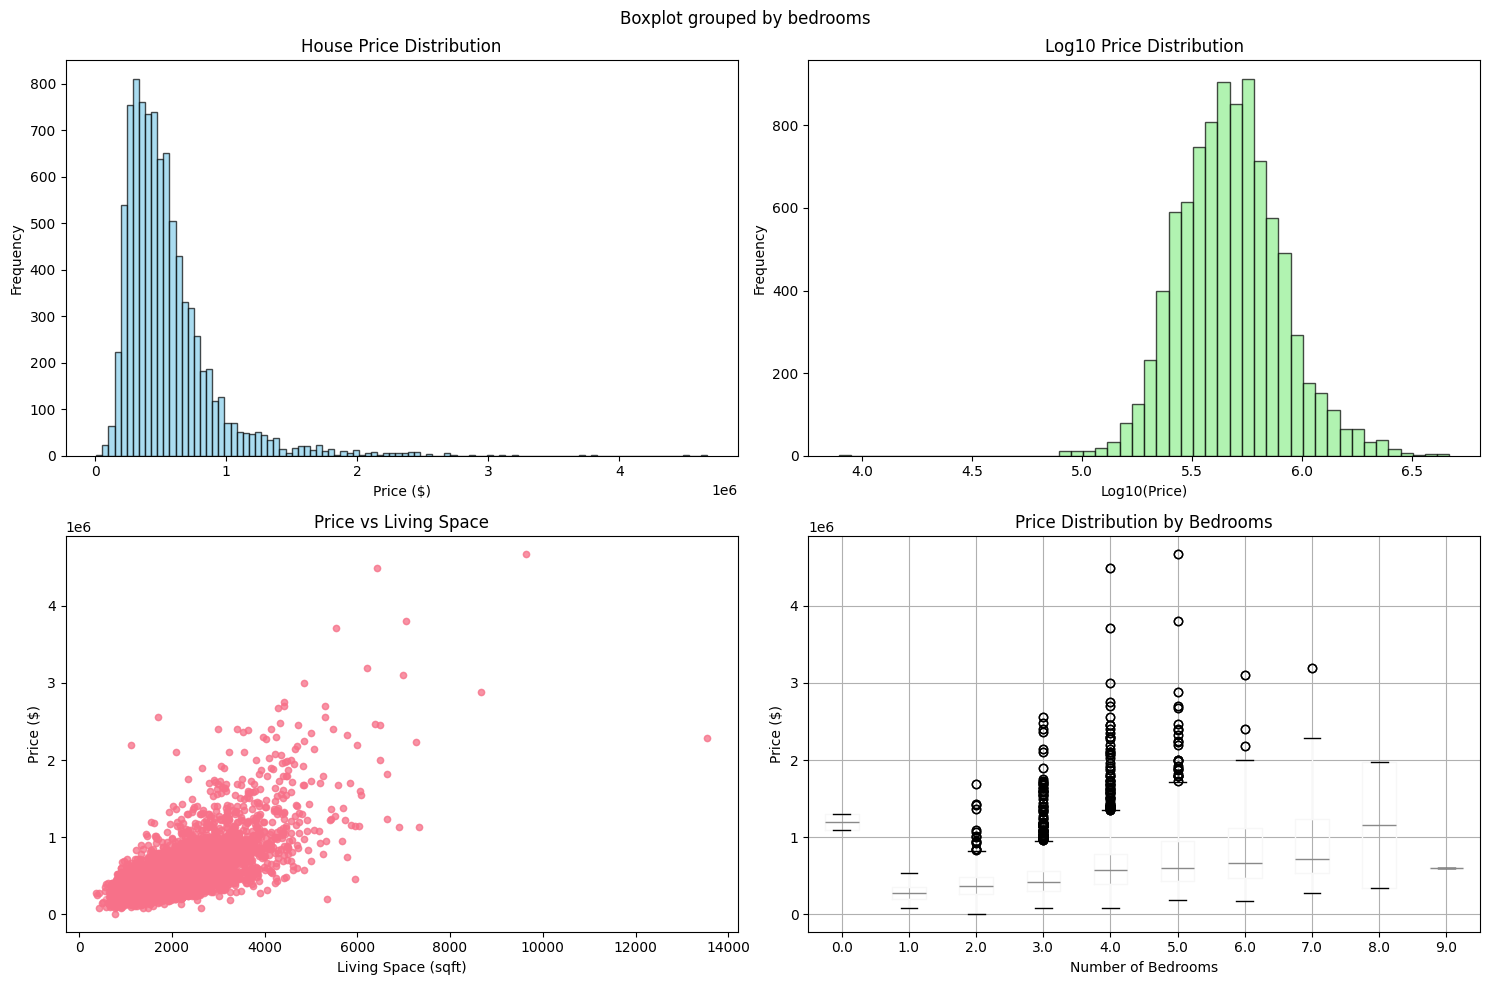

In [58]:
#DATA EXPLORATION

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
fig_size = (15, 10)

# 1. Price Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=fig_size)

# Price histogram
# axes[0,0].hist(df_clean['price'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].hist(df_clean['price'], bins=100, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('House Price Distribution')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Frequency')

# Log-transformed price (often more normal)
axes[0,1].hist(np.log10(df_clean['price']), bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].set_title('Log10 Price Distribution')
axes[0,1].set_xlabel('Log10(Price)')
axes[0,1].set_ylabel('Frequency')

# Price vs Living Space
axes[1,0].scatter(df_clean['sqft_living'], df_clean['price'], alpha=0.5, s=20)
axes[1,0].set_title('Price vs Living Space')
axes[1,0].set_xlabel('Living Space (sqft)')
axes[1,0].set_ylabel('Price ($)')

# Boxplot of price by number of bedrooms
df_clean.boxplot(column='price', by='bedrooms', ax=axes[1,1])
axes[1,1].set_title('Price Distribution by Bedrooms')
axes[1,1].set_xlabel('Number of Bedrooms')
axes[1,1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()


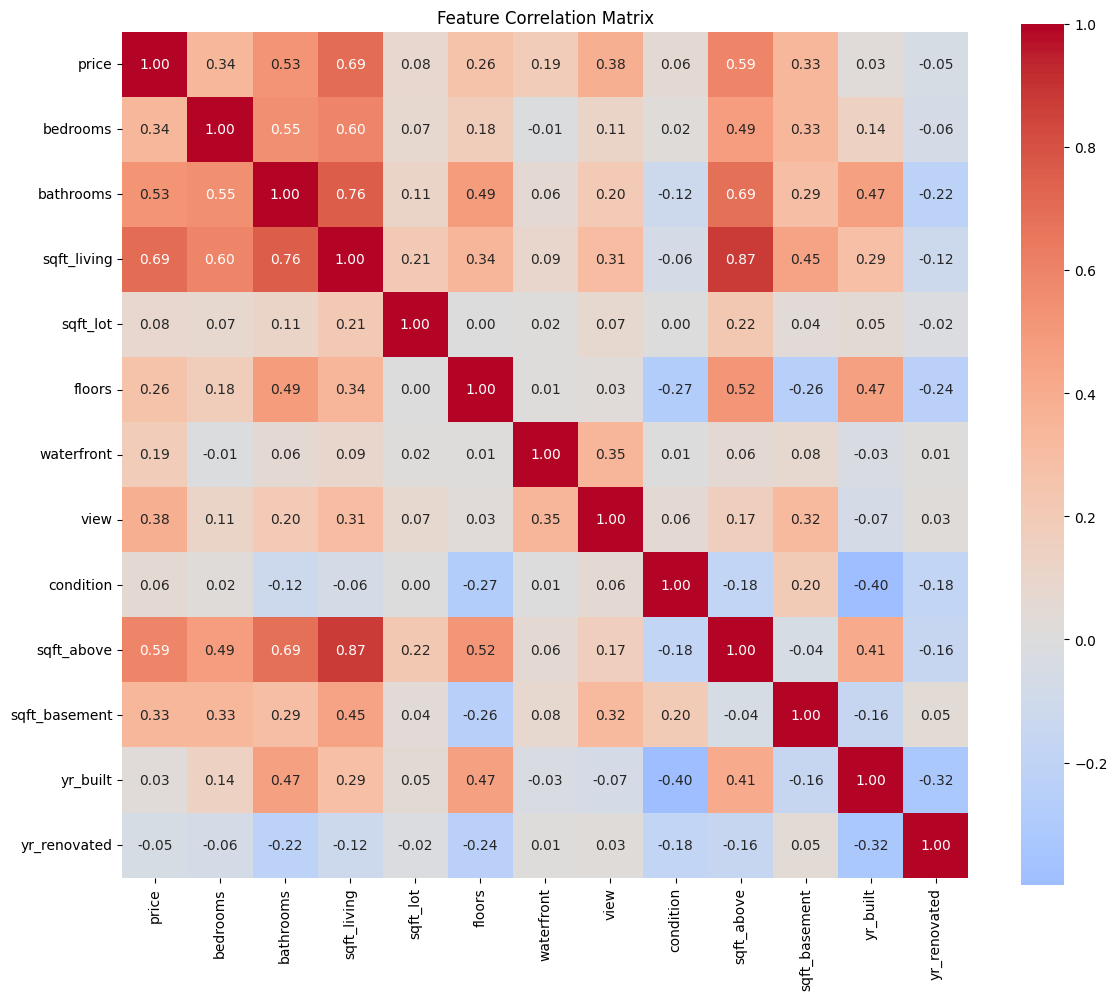


=== TOP PRICE CORRELATIONS ===
sqft_living      0.694668
sqft_above       0.594288
bathrooms        0.529689
view             0.383297
bedrooms         0.337051
sqft_basement    0.333939
floors           0.261500
waterfront       0.193942
sqft_lot         0.082877
condition        0.056373
yr_renovated     0.047015
yr_built         0.031033
Name: price, dtype: float64


In [ ]:

# Feature Correlation Analysis (numerical features)

# Select numerical columns for correlation
numerical_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 
                  'floors', 'waterfront', 'view', 'condition', 'sqft_above', 
                  'sqft_basement', 'yr_built', 'yr_renovated']

correlation_matrix = df_clean[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Top correlations with price
price_corr = correlation_matrix['price'].abs().sort_values(ascending=False)
print("\n=== TOP PRICE CORRELATIONS ===")
print(price_corr[1:])  # Exclude price correlation with itself


In [60]:
#check VIF redundant features

import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Select the numeric features you are considering for your model
features = [
    'sqft_living', 'sqft_above', 'bathrooms', 'view', 
    'bedrooms', 'sqft_basement', 'floors', 'waterfront', 
    'sqft_lot', 'condition', 'yr_renovated', 'yr_built'
]

# 2. Filter the dataframe and drop any rows with NaN values (VIF can't handle NaNs)
X = df_clean[features].dropna()

# 3. Add a constant column (intercept) - Required for VIF
X_with_const = add_constant(X)

# 4. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                  for i in range(X_with_const.shape[1])]

# 5. Display results (excluding the constant row for clarity)
print(vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF", ascending=False))


          Feature          VIF
1     sqft_living  3895.027861
2      sqft_above  3130.267794
6   sqft_basement   918.525401
3       bathrooms     3.266422
12       yr_built     1.903429
7          floors     1.877827
5        bedrooms     1.684190
10      condition     1.434266
4            view     1.333296
11   yr_renovated     1.318363
8      waterfront     1.141971
9        sqft_lot     1.076333


In [ ]:
# Geographic and Categorical Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Price by city
city_prices = df_clean.groupby('city')['price'].agg(['mean', 'count']).sort_values('mean', ascending=False)
top_cities = city_prices[city_prices['count'] >= 10].head(10)  # Cities with at least 10 properties

axes[0,0].bar(range(len(top_cities)), top_cities['mean'], color='coral')
axes[0,0].set_title('Average Price by City (Top 10)')
axes[0,0].set_xlabel('Cities')
axes[0,0].set_ylabel('Average Price ($)')
axes[0,0].set_xticks(range(len(top_cities)))
axes[0,0].set_xticklabels(top_cities.index, rotation=45, ha='right')

# Price by condition
condition_prices = df_clean.groupby('condition')['price'].mean().sort_index()
axes[0,1].bar(condition_prices.index, condition_prices.values, color='lightblue')
axes[0,1].set_title('Average Price by Condition Rating')
axes[0,1].set_xlabel('Condition (1-5)')
axes[0,1].set_ylabel('Average Price ($)')

# Waterfront premium
waterfront_prices = df_clean.groupby('waterfront')['price'].mean()
axes[1,0].bar(['No Waterfront', 'Waterfront'], waterfront_prices.values, 
              color=['lightcoral', 'darkblue'])
axes[1,0].set_title('Price: Waterfront vs Non-Waterfront')
axes[1,0].set_ylabel('Average Price ($)')

# Year built distribution
axes[1,1].hist(df_clean['yr_built'], bins=30, alpha=0.7, color='gold', edgecolor='black')
axes[1,1].set_title('Distribution of Year Built')
axes[1,1].set_xlabel('Year Built')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()
